# False alarm rate simulation

Empirical false alarm rate of the `CUSUM` detector under the null (i.i.d. standard normal data) as a function of stream length. The threshold is calibrated to a target false alarm probability over a stream of length $T$, and we verify that the realized false alarm rate stays controlled as the stream grows way beyond this point.

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np

from gridcp import GridDetector
from gridcp.calibration import (
    calibrate_threshold_false_alarm,
    mc_alarm_times,
    with_calibrated_threshold,
)
from gridcp.scores import CUSUM

In [26]:
# Warning: This takes a long time (approx. ... minutes with a MacBook pro with M5 pro chip) to run when N_SIM set to 1 million, 
# which is needed to reproduce the exact plot from the paper.
ALPHA = 0.05      # Target false alarm probability
N_CAL = 100       # Calibration stream length (T)
K_CAL = 1_000_000    # Number of paths to simulate for calibration
K_SIM = 1_000_000    # Number of null paths to simulate for estimating the false alarm rate
L_MAX = 10_000    # Maximum stream length to simulate for estimating the false alarm rate
N_JOBS = 18       # For reproducibility of the plots in the paper, 18 workers must be used
RNG_CAL = 0
RNG_SIM = 1

# Sampler function for sampling from the null, i.e. a standard normal distribution
def sampler(rng):
    return rng.standard_normal()

## Calibrate threshold

In [ ]:
score = CUSUM()
detector = GridDetector(score=score)

# Calibrate threshold
start_time = time.perf_counter()
threshold = calibrate_threshold_false_alarm(
    score,
    false_alarm_probability=ALPHA,
    n_paths=K_CAL,
    stream_len=N_CAL,
    pre_sampler=sampler,
    rng=RNG_CAL,
    n_jobs=N_JOBS
)
print(f"Calibration done in {time.perf_counter() - start_time:.1f}s. Threshold: {threshold[0]:.4f}")

Calibration done in 103.4s. Threshold: 3.0153


## Simulate alarm times under the null

In [27]:
detector_cal = with_calibrated_threshold(detector, threshold)
alarm_times = mc_alarm_times(detector_cal, K_SIM, L_MAX, pre_sampler=sampler, rng=RNG_SIM, n_jobs=N_JOBS)

## False alarm rate over the stream length

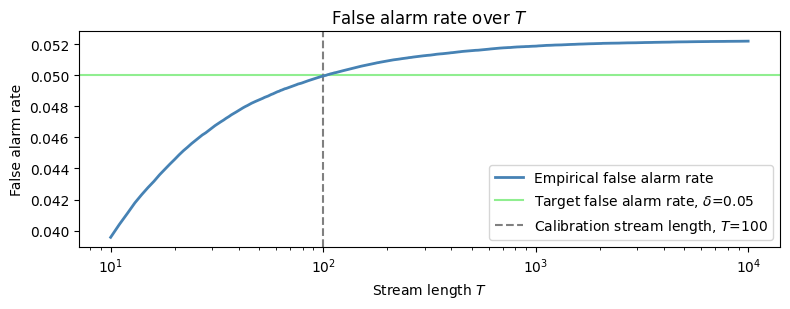

In [33]:
Ts = np.unique(np.geomspace(N_CAL // 10, L_MAX, 5_000).astype(int))
at_sorted = np.sort(alarm_times)
far_curve = np.searchsorted(at_sorted, Ts, side="left") / K_SIM

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(
    Ts[:-1],
    far_curve[:-1],
    color="steelblue",
    linewidth=2,
    label="Empirical false alarm rate",
)
ax.axhline(
    ALPHA,
    color="lightgreen",
    label=rf"Target false alarm rate, $\delta$={ALPHA}",
    zorder=1
)
ax.axvline(
    N_CAL,
    color="gray",
    linestyle="--",
    label=f"Calibration stream length, $T$={N_CAL}",
    zorder=1
)
ax.set_xscale("log")
ax.set_xlabel("Stream length $T$")
ax.set_ylabel("False alarm rate")
ax.set_title("False alarm rate over $T$")
ax.legend()
plt.tight_layout()
plt.savefig("fa_rate.pdf", bbox_inches="tight")
plt.show()